# Workout Class Classifier - Bidirectional GRU

This notebook trains a Bidirectional GRU (BiGRU) classifier to predict workout classes from pose sequences.

The model:
- Takes sequences of shape (15, 12, 3) - 15 frames, 12 landmarks, 3 coordinates
- Reshapes to (15, 36) - 15 timesteps, 36 features per timestep (12 landmarks × 3 coords)
- Uses Bidirectional GRU to capture temporal patterns in both directions
- GRU is faster and more efficient than LSTM while maintaining good performance
- Predicts workout classes using a dense output layer

In [1]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.18.0
Keras version: 3.7.0


## Load Training Data

In [2]:
# Load training data from .npz file
data_path = Path('../../Data/output/training_data.npz')
metadata_path = Path('../../Data/output/training_data_metadata.json')

# Load metadata
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

print("Dataset Metadata:")
print(f"  Number of samples: {metadata['n_samples']}")
print(f"  Number of classes: {metadata['n_classes']}")
print(f"  Sequence length: {metadata['sequence_length']}")
print(f"  Number of landmarks: {metadata['n_landmarks']}")
print(f"  Number of coordinates: {metadata['n_coords']}")
print(f"  Feature shape: {metadata['feature_shape']}")
print(f"\nClass names: {metadata['class_names']}")
print(f"\nClass distribution:")
for cls, count in metadata['class_distribution'].items():
    print(f"  {cls}: {count}")

# Load the .npz file
data = np.load(data_path, allow_pickle=True)

# Load data
X = data['X']  # Shape: (n_samples, 15, 12, 3)
y_encoded = data['y']  # Encoded labels (integers)
y_raw = data['y_raw']  # Raw class names
class_names = data['class_names']  # Class names array

print(f"\nLoaded data shapes:")
print(f"  X shape: {X.shape}")
print(f"  y_encoded shape: {y_encoded.shape}")
print(f"  Number of classes: {len(class_names)}")

Dataset Metadata:
  Number of samples: 7112
  Number of classes: 16
  Sequence length: 15
  Number of landmarks: 12
  Number of coordinates: 3
  Feature shape: [15, 12, 3]

Class names: ['barbell biceps curl', 'bench press', 'chest fly machine', 'deadlift', 'incline bench press', 'lat pulldown', 'lateral raise', 'leg extension', 'leg raises', 'push-up', 'russian twist', 'shoulder press', 'squat', 't bar row', 'tricep Pushdown', 'tricep dips']

Class distribution:
  barbell biceps curl: 472
  bench press: 416
  chest fly machine: 340
  deadlift: 346
  incline bench press: 478
  lat pulldown: 420
  lateral raise: 558
  leg extension: 388
  leg raises: 364
  push-up: 670
  russian twist: 368
  shoulder press: 346
  squat: 570
  t bar row: 486
  tricep Pushdown: 394
  tricep dips: 496

Loaded data shapes:
  X shape: (7112, 15, 12, 3)
  y_encoded shape: (7112,)
  Number of classes: 16


## Preprocess Data

Reshape sequences from (15, 12, 3) to (15, 36) for GRU input - each timestep contains flattened landmark coordinates.

In [3]:
# Reshape sequences: (n_samples, 15, 12, 3) -> (n_samples, 15, 36)
# Each timestep (frame) contains 12 landmarks × 3 coordinates = 36 features
X_reshaped = X.reshape(X.shape[0], X.shape[1], -1)
print(f"Reshaped X shape: {X_reshaped.shape}")
print(f"  - {X_reshaped.shape[0]} samples")
print(f"  - {X_reshaped.shape[1]} timesteps (frames)")
print(f"  - {X_reshaped.shape[2]} features per timestep")

# Check for NaN or infinite values
print(f"\nData quality check:")
print(f"  NaN values in X: {np.isnan(X_reshaped).sum()}")
print(f"  Infinite values in X: {np.isinf(X_reshaped).sum()}")

# Replace any NaN or infinite values with 0
X_reshaped = np.nan_to_num(X_reshaped, nan=0.0, posinf=0.0, neginf=0.0)

# Normalize the data (important for neural networks)
# Calculate mean and std from training data
X_mean = np.mean(X_reshaped, axis=(0, 1), keepdims=True)
X_std = np.std(X_reshaped, axis=(0, 1), keepdims=True) + 1e-8  # Add small epsilon to avoid division by zero

# Normalize
X_normalized = (X_reshaped - X_mean) / X_std
print(f"\nData normalized: mean={X_mean.mean():.4f}, std={X_std.mean():.4f}")

# Convert labels to categorical (one-hot encoding) for neural network
y_categorical = keras.utils.to_categorical(y_encoded, num_classes=len(class_names))
print(f"y_categorical shape: {y_categorical.shape}")

Reshaped X shape: (7112, 15, 36)
  - 7112 samples
  - 15 timesteps (frames)
  - 36 features per timestep

Data quality check:
  NaN values in X: 0
  Infinite values in X: 0

Data normalized: mean=0.2081, std=0.3480
y_categorical shape: (7112, 16)


## Split Data into Train and Test Sets

In [4]:
# Split data into train and test sets
X_train, X_test, y_train_cat, y_test_cat, y_train_encoded, y_test_encoded = train_test_split(
    X_normalized, y_categorical, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Ensure balanced split across classes
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Sequence shape: {X_train.shape[1:]} (timesteps, features)")
print(f"Number of classes: {len(class_names)}")

Training set size: 5689
Test set size: 1423
Sequence shape: (15, 36) (timesteps, features)
Number of classes: 16


## Build BiGRU Model

Create a Bidirectional GRU model with:
- Input layer for sequences
- Bidirectional GRU layers to capture temporal patterns
- Dropout for regularization
- Dense layers for classification

In [5]:
# Model parameters
n_timesteps = X_train.shape[1]  # 15 frames
n_features = X_train.shape[2]    # 36 features per timestep (12 landmarks × 3 coords)
n_classes = len(class_names)     # 22 workout classes

# Build the model
model = models.Sequential([
    # Input layer
    layers.Input(shape=(n_timesteps, n_features)),
    
    # First Bidirectional GRU layer
    layers.Bidirectional(
        layers.GRU(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        name='bigru_1'
    ),

    layers.Bidirectional(
        layers.GRU(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        name='bigru_2'
    ),
    
    # Second Bidirectional GRU layer
    layers.Bidirectional(
        layers.GRU(128, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
        name='bigru_3'
    ),
    
    # Dense layer with dropout
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dropout(0.3, name='dropout_1'),
    
    # Output layer
    layers.Dense(n_classes, activation='softmax', name='output')
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bigru_1 (Bidirectional)         │ (None, 15, 512)        │       451,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_2 (Bidirectional)         │ (None, 15, 512)        │     1,182,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_3 (Bidirectional)         │ (None, 256)            │       493,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,144,848 (8.18 MB)

 Trainable params: 2,144,848 (8.18 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

Train the BiGRU model with early stopping and model checkpointing.

In [6]:
# Define callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Create models directory if it doesn't exist
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(models_dir / 'gru_workout_classifier_best.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Training parameters
batch_size = 32
epochs = 100

print("Training BiGRU model...")
print(f"Batch size: {batch_size}")
print(f"Max epochs: {epochs}")

# Train the model
history = model.fit(
    X_train, y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("\nTraining completed!")

Training BiGRU model...
Batch size: 32
Max epochs: 100
Epoch 1/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3047 - loss: 2.2193
Epoch 1: val_accuracy improved from -inf to 0.50878, saving model to models/gru_workout_classifier_best.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.3051 - loss: 2.2176 - val_accuracy: 0.5088 - val_loss: 1.5654 - learning_rate: 0.0010
Epoch 2/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4938 - loss: 1.5093
Epoch 2: val_accuracy improved from 0.50878 to 0.57414, saving model to models/gru_workout_classifier_best.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - accuracy: 0.4939 - loss: 1.5090 - val_accuracy: 0.5741 - val_loss: 1.4006 - learning_rate: 0.0010
Epoch 3/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5698 - loss: 1.2616
Epoch 3: val_accuracy improved from 0.57414 to 0.64441, saving model to models/gru_workout_classifier_best.keras
178/178 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy

## Training History Visualization

Plot training and validation accuracy/loss over epochs.

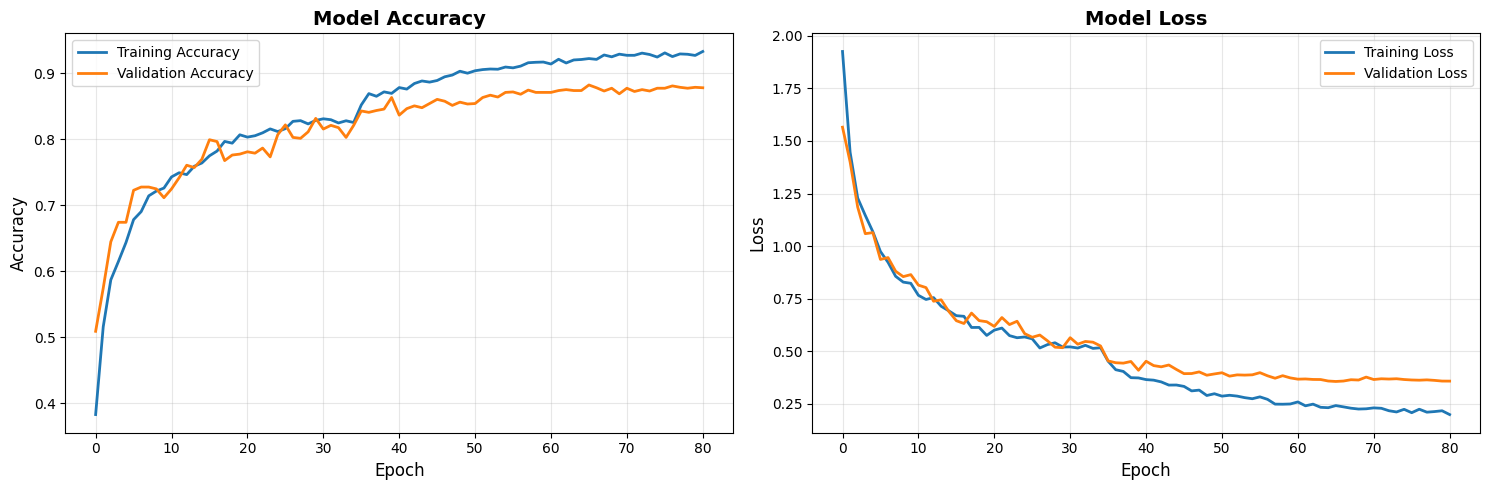


Final Training Metrics:
  Accuracy: 0.9327 (93.27%)
  Loss: 0.1992

Final Validation Metrics:
  Accuracy: 0.8777 (87.77%)
  Loss: 0.3582


In [7]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Training Metrics:")
print(f"  Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Loss: {final_train_loss:.4f}")
print(f"\nFinal Validation Metrics:")
print(f"  Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Loss: {final_val_loss:.4f}")

## Evaluate Model

Make predictions and evaluate the model performance on the test set.

In [8]:
# Make predictions
y_pred_proba = model.predict(X_test, verbose=0)  # Shape: (n_test_samples, n_classes)
y_pred_encoded = np.argmax(y_pred_proba, axis=1)  # Predicted class indices

print("Predictions shape:")
print(f"  y_pred_proba shape: {y_pred_proba.shape}")
print(f"  y_pred_encoded shape: {y_pred_encoded.shape}")

# Calculate accuracy
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Predictions shape:
  y_pred_proba shape: (1423, 16)
  y_pred_encoded shape: (1423,)

Test Accuracy: 0.8819 (88.19%)


## Detailed Classification Report

In [9]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test_encoded, 
    y_pred_encoded, 
    target_names=class_names,
    digits=3
))


Classification Report:
                     precision    recall  f1-score   support

barbell biceps curl      0.961     0.787     0.865        94
        bench press      0.640     0.687     0.663        83
  chest fly machine      0.905     0.985     0.944        68
           deadlift      0.862     0.812     0.836        69
incline bench press      0.770     0.802     0.786        96
       lat pulldown      0.859     0.869     0.864        84
      lateral raise      0.871     0.964     0.915       112
      leg extension      0.971     0.846     0.904        78
         leg raises      0.986     0.932     0.958        73
            push-up      0.969     0.918     0.943       134
      russian twist      0.971     0.919     0.944        74
     shoulder press      0.780     0.928     0.848        69
              squat      0.954     0.912     0.933       114
          t bar row      0.814     0.948     0.876        97
    tricep Pushdown      0.857     0.911     0.883        79

## Confusion Matrix

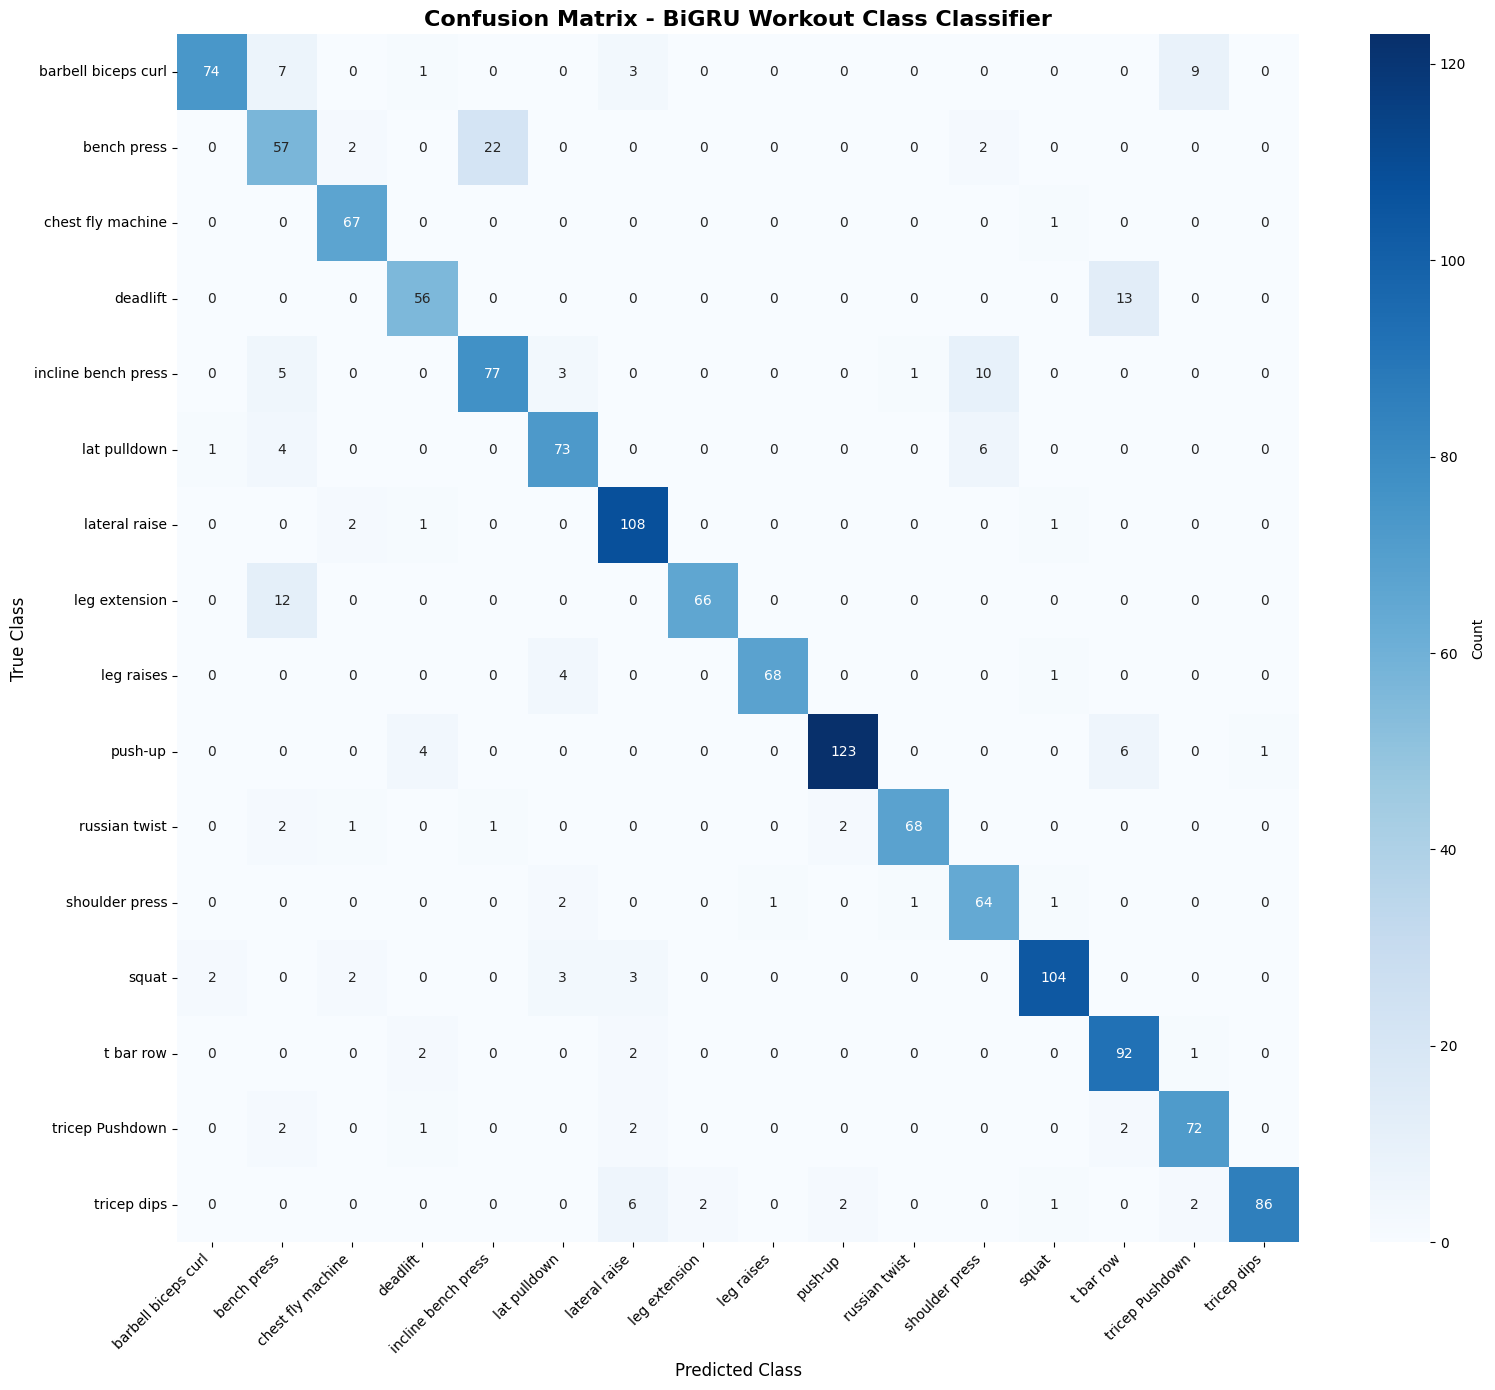


Per-Class Accuracy:
  barbell biceps curl: 0.7872 (78.72%)
  bench press: 0.6867 (68.67%)
  chest fly machine: 0.9853 (98.53%)
  deadlift: 0.8116 (81.16%)
  incline bench press: 0.8021 (80.21%)
  lat pulldown: 0.8690 (86.90%)
  lateral raise: 0.9643 (96.43%)
  leg extension: 0.8462 (84.62%)
  leg raises: 0.9315 (93.15%)
  push-up: 0.9179 (91.79%)
  russian twist: 0.9189 (91.89%)
  shoulder press: 0.9275 (92.75%)
  squat: 0.9123 (91.23%)
  t bar row: 0.9485 (94.85%)
  tricep Pushdown: 0.9114 (91.14%)
  tricep dips: 0.8687 (86.87%)


In [10]:
# Create confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - BiGRU Workout Class Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
for i, cls_name in enumerate(class_names):
    print(f"  {cls_name}: {per_class_accuracy[i]:.4f} ({per_class_accuracy[i]*100:.2f}%)")

## Example Predictions

Show some example predictions with probabilities.

In [11]:
# Show some example predictions
n_examples = 10
example_indices = np.random.choice(len(X_test), n_examples, replace=False)

print("Example Predictions:")
print("=" * 80)
for idx in example_indices:
    true_class_idx = y_test_encoded[idx]
    pred_class_idx = y_pred_encoded[idx]
    true_class = class_names[true_class_idx]
    pred_class = class_names[pred_class_idx]
    probabilities = y_pred_proba[idx]
    
    # Get top 3 predicted classes
    top3_indices = np.argsort(probabilities)[-3:][::-1]
    
    print(f"\nSample {idx}:")
    print(f"  True class: {true_class}")
    print(f"  Predicted class: {pred_class} {'✓' if true_class == pred_class else '✗'}")
    print(f"  Top 3 predictions:")
    for i, class_idx in enumerate(top3_indices):
        print(f"    {i+1}. {class_names[class_idx]}: {probabilities[class_idx]:.4f}")

Example Predictions:

Sample 1185:
  True class: leg raises
  Predicted class: leg raises ✓
  Top 3 predictions:
    1. leg raises: 0.9964
    2. lat pulldown: 0.0028
    3. shoulder press: 0.0005

Sample 677:
  True class: push-up
  Predicted class: push-up ✓
  Top 3 predictions:
    1. push-up: 0.9941
    2. deadlift: 0.0028
    3. t bar row: 0.0011

Sample 1084:
  True class: tricep Pushdown
  Predicted class: tricep Pushdown ✓
  Top 3 predictions:
    1. tricep Pushdown: 0.9576
    2. barbell biceps curl: 0.0218
    3. lateral raise: 0.0106

Sample 1005:
  True class: lat pulldown
  Predicted class: lat pulldown ✓
  Top 3 predictions:
    1. lat pulldown: 0.9973
    2. incline bench press: 0.0013
    3. shoulder press: 0.0012

Sample 944:
  True class: chest fly machine
  Predicted class: chest fly machine ✓
  Top 3 predictions:
    1. chest fly machine: 0.9880
    2. squat: 0.0082
    3. lateral raise: 0.0014

Sample 538:
  True class: leg raises
  Predicted class: leg raises ✓
  

## Save Model

Save the trained model and metadata for future use.

In [12]:
# Save the final model
model_path = models_dir / 'gru_workout_classifier.keras'
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save class names for reference
class_names_path = models_dir / 'class_names_gru.json'
with open(class_names_path, 'w') as f:
    json.dump(class_names.tolist(), f, indent=2)
print(f"Class names saved to: {class_names_path}")

# Save normalization parameters
normalization_params = {
    'mean': X_mean.tolist(),
    'std': X_std.tolist()
}
norm_params_path = models_dir / 'normalization_params_gru.json'
with open(norm_params_path, 'w') as f:
    json.dump(normalization_params, f, indent=2)
print(f"Normalization parameters saved to: {norm_params_path}")

# Save metadata about the model
model_metadata = {
    'model_type': 'BiGRU',
    'n_classes': len(class_names),
    'n_timesteps': n_timesteps,
    'n_features': n_features,
    'sequence_shape': [n_timesteps, n_features],
    'class_names': class_names.tolist(),
    'test_accuracy': float(accuracy),
    'model_path': str(model_path),
    'class_names_path': str(class_names_path),
    'normalization_params_path': str(norm_params_path),
    'model_architecture': {
        'layers': [
            {'type': 'Bidirectional GRU', 'units': 128, 'return_sequences': True},
            {'type': 'Bidirectional GRU', 'units': 64, 'return_sequences': False},
            {'type': 'Dense', 'units': 64, 'activation': 'relu'},
            {'type': 'Dense', 'units': n_classes, 'activation': 'softmax'}
        ]
    }
}

metadata_path = models_dir / 'model_metadata_gru.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"Model metadata saved to: {metadata_path}")

Model saved to: models/gru_workout_classifier.keras
Class names saved to: models/class_names_gru.json
Normalization parameters saved to: models/normalization_params_gru.json
Model metadata saved to: models/model_metadata_gru.json


## Prediction Function

Helper function to make predictions on new sequences.

In [13]:
def predict_workout_class(sequence, model, class_names, normalization_params=None, return_proba=False):
    """
    Predict workout class for a sequence.
    
    Args:
        sequence: numpy array of shape (15, 12, 3) or (1, 15, 12, 3) or (15, 36) or (1, 15, 36)
        model: Trained BiGRU model
        class_names: Array of class names
        normalization_params: Dict with 'mean' and 'std' for normalization (optional)
        return_proba: If True, return probabilities for all classes, else return class name
    
    Returns:
        If return_proba=True: probability array of shape (n_classes,)
        If return_proba=False: predicted class name (string)
    """
    # Reshape sequence to (n_samples, 15, 36)
    if sequence.ndim == 3:
        if sequence.shape[2] == 3:
            # Shape is (15, 12, 3) - reshape to (1, 15, 36)
            sequence = sequence.reshape(1, sequence.shape[0], -1)
        else:
            # Shape is (1, 15, 36) or (15, 36)
            if sequence.shape[0] == 15:
                sequence = sequence.reshape(1, *sequence.shape)
            else:
                sequence = sequence.reshape(sequence.shape[0], sequence.shape[1], -1)
    elif sequence.ndim == 4:
        # Shape is (n, 15, 12, 3) - reshape to (n, 15, 36)
        sequence = sequence.reshape(sequence.shape[0], sequence.shape[1], -1)
    
    # Handle NaN and infinite values
    sequence = np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Normalize if parameters provided
    if normalization_params is not None:
        mean = np.array(normalization_params['mean'])
        std = np.array(normalization_params['std'])
        sequence = (sequence - mean) / std
    
    # Get probabilities
    probabilities = model.predict(sequence, verbose=0)
    
    if return_proba:
        # Return probabilities
        return probabilities[0] if probabilities.shape[0] == 1 else probabilities
    else:
        # Return class name
        pred_class_idx = np.argmax(probabilities, axis=1)
        if len(pred_class_idx) == 1:
            return class_names[pred_class_idx[0]]
        else:
            return [class_names[idx] for idx in pred_class_idx]

# Test the prediction function
print("Testing prediction function:")
test_sequence = X[0]  # Original shape (15, 12, 3)
pred_class = predict_workout_class(
    test_sequence, 
    model, 
    class_names, 
    normalization_params={'mean': X_mean.tolist(), 'std': X_std.tolist()},
    return_proba=False
)
pred_proba = predict_workout_class(
    test_sequence, 
    model, 
    class_names,
    normalization_params={'mean': X_mean.tolist(), 'std': X_std.tolist()},
    return_proba=True
)

print(f"  Input shape: {test_sequence.shape}")
print(f"  Predicted class: {pred_class}")
print(f"  Probabilities shape: {pred_proba.shape}")
print(f"  Top 3 class probabilities:")
top3_indices = np.argsort(pred_proba)[-3:][::-1]
for i, idx in enumerate(top3_indices):
    print(f"    {i+1}. {class_names[idx]}: {pred_proba[idx]:.4f}")
print(f"  True class: {class_names[y_encoded[0]]}")

Testing prediction function:
  Input shape: (15, 12, 3)
  Predicted class: barbell biceps curl
  Probabilities shape: (16,)
  Top 3 class probabilities:
    1. barbell biceps curl: 0.5386
    2. leg raises: 0.3795
    3. squat: 0.0677
  True class: barbell biceps curl
